In [25]:
import random

import mlflow
import numpy as np
import pyarrow.parquet as pq
import torch.cuda
from torch import nn
from torch.utils.data import Dataset, WeightedRandomSampler, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH = 128
EPOCHS = 30
LR = 1e-3
NUM_CLASSES = 8
DATA_DIR = "../data/processed"

print(f"Device: {DEVICE}")

Device: cpu


In [26]:
LABELS = ["Center", "Donut", "Edge-Loc", "Edge-Ring", "Loc", "Near-full", "Random", "Scratch"]
LABEL2IDX = {name: i for i, name in enumerate(LABELS)}


class WaferDataset(Dataset):
    def __init__(self, parquet_path: str):
        table = pq.read_table(parquet_path)
        df = table.to_pandas()
        wafers = np.stack(df["wafer"].values)
        self.X = wafers.reshape(-1, 1, 64, 64).astype(np.float32)
        self.y = df["label"].map(LABEL2IDX).values.astype(np.int64)
        assert not np.isnan(self.y).any(), "Unknown label found"

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]), int(self.y[idx])


train_ds = WaferDataset(f"{DATA_DIR}/train.parquet")
val_ds = WaferDataset(f"{DATA_DIR}/val.parquet")
test_ds = WaferDataset(f"{DATA_DIR}/test.parquet")

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
print(f"X shape={train_ds.X.shape}, dtype={train_ds.X.dtype}")


Train: 17863, Val: 3828, Test: 3828
X shape=(17863, 1, 64, 64), dtype=float32


In [27]:
# count samples per classes in the training set
class_counts = np.bincount(train_ds.y, minlength=NUM_CLASSES)
for i, name in enumerate(LABELS):
    print(f"{name:12s}: {class_counts[i]}")

# Weight per class = inverse frequency -> rare classes get higher weight
class_weights = 1.0 / class_counts
# Assign each sample the weight of its class
sample_weights = class_weights[train_ds.y]
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).double(),  # sampler requires float64
    num_samples=len(sample_weights),  # keep one epoch ~= dataset size
    replacement=True
)

print(f"Sampler ready, {len(sample_weights)} samples")

Center      : 3006
Donut       : 389
Edge-Loc    : 3632
Edge-Ring   : 6776
Loc         : 2515
Near-full   : 104
Random      : 606
Scratch     : 835
Sampler ready, 17863 samples


In [28]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH,
    sampler=sampler,  # weighted sampling -> no shuffle (sample controls order)
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH,
    shuffle=False,  # natural distribution, order irrelevant for eval
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

# Sanity check
xb, yb = next(iter(train_loader))
print(f"batch X: {xb.shape}  {yb.dtype}")  # expect [128, 1, 64, 64] float32
print(f"batch y: {yb.shape}  {yb.dtype}")  # expect [128] int64
print(f"class count in this batch: {np.bincount(yb.numpy(), minlength=NUM_CLASSES)}")

batch X: torch.Size([128, 1, 64, 64])  torch.int64
batch y: torch.Size([128])  torch.int64
class count in this batch: [13 22 17 15 15 14 10 22]


In [29]:
class WaferCNN(nn.Module):
    """Small baseline CNN for 64x64 single channel wafer maps."""

    def __init__(self, num_classes: int = NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            # block 1: 1-> 32, 64x64 -> 32 x 32
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # block 2: 32 -> 64, 32 x 32 -> 16 x 16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # block 3: 64 -> 128, 16 x 16 -> 8 x 8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # 128x8x8 -> 128x1x1, robust to size changes
            nn.Flatten(),  # -> [N, 128]
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = x / 2.0  # normalize die values {0, 1, 2} -> {0, 0.5, 1.0}
        x = self.features(x)
        x = self.classifier(x)
        return x


model = WaferCNN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"trainable params: {n_params:,}")

for name, p in model.named_parameters():
    print(f"{name:35s} {str(type(p.shape)):20s} {p.numel():>8,}")

# Forward sanity check on each batch
with torch.no_grad():
    out = model(xb.to(DEVICE))
print(f"output shape: {out.shape}")  # expect [128,8]

WaferCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim

In [30]:
# γ và β init of BatchNorm — weight = γ, bias = β
bn = model.features[1]  # BatchNorm2d(32)
print("γ (weight):", bn.weight.data[:5])  # all 1.0
print("β (bias):  ", bn.bias.data[:5])  # all 0.0

# He-init randomly
conv = model.features[0]  # Conv2d(1, 32)
print("conv weight:", conv.weight.data[0, 0])  # 3×3 random small number

γ (weight): tensor([1., 1., 1., 1., 1.])
β (bias):   tensor([0., 0., 0., 0., 0.])
conv weight: tensor([[ 0.2048,  0.1338,  0.2557],
        [-0.2877,  0.2651, -0.0399],
        [-0.0570,  0.1748,  0.0881]])


In [31]:
from pathlib import Path

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam, a solid default for CNNs
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Mlflow: point to a local tracking dir and name the experiment
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
db_path = PROJECT_ROOT / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{db_path}")
mlflow.set_experiment("wm811k-baseline-cnn")

print("criterion, optimizer, and experiment set up!")

criterion, optimizer, and experiment set up!


In [32]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()  # enable Dropout + BatchNorm use batch stats
    running_loss = 0.0
    n_samples = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()  # clear gradients from previous step
        logits = model(xb)  # forward
        loss = criterion(logits, yb)  # how wrong
        loss.backward()  # backprop: compute gradients
        optimizer.step()  # nudge parameters

        running_loss += loss.item() * xb.size(0)
        n_samples += xb.size(0)
    return running_loss / n_samples


@torch.no_grad()  # no gradients needed for eval -> faster, less memory
def evaluate(model, loader, criterion, device):
    model.eval()  # disables Dropout + BatchNorm uses running stats
    running_loss = 0.0
    n_samples = 0
    all_preds, all_labels = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)

        running_loss += loss.item() * xb.size(0)
        n_samples += xb.size(0)
        all_preds.append(logits.argmax(dim=1).cpu())
        all_labels.append(yb.cpu())

    avg_loss = running_loss / n_samples
    preds = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    return avg_loss, preds, labels


print("train/eval functions ready!")

train/eval functions ready!


In [33]:
# Macro-F1: unweighted mean over classes -> rare classes count equally
from sklearn.metrics import f1_score

best_val_loss = float("inf")
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)
best_path = MODEL_DIR / "wafercnn_best.pt"

# Params logged once per run for reproducibility
run_params = {
    "model": "WaferCNN",
    "epochs": EPOCHS,
    "batch_size": BATCH,
    "lr": LR,
    "optimizer": "Adam",
    "loss": "CrossEntropyLoss",
    "sampler": "WeightedRandomSampler",
    "seed": SEED,
    "img_size": 64,
    "num_classes": NUM_CLASSES,
}

with mlflow.start_run(run_name="baseline-cnn"):
    mlflow.log_params(run_params)
    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model=model, loader=train_loader, criterion=criterion, optimizer=optimizer, device=DEVICE)
        val_loss, val_preds, val_labels = evaluate(model=model, loader=val_loader, criterion=criterion, device=DEVICE)
        val_macro_f1 = f1_score(y_true=val_labels, y_pred=val_preds, average="macro")

        mlflow.log_metrics(
            metrics={
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_macro_f1": val_macro_f1,
            }, step=epoch
        )

        print(
            f"epoch {epoch:2d} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | val macro-F1: {val_macro_f1:.4f}")

        # Save the best by val_loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_path)
            mlflow.log_artifact(str(best_path))
            print(f"\t-> saved best (val_loss {val_loss:.4f})")

print(f"\nDone! Best val_loss: {best_val_loss:.4f}")

epoch  1 | train loss: 1.1472 | val loss: 0.9288 | val macro-F1: 0.5371
	-> saved best (val_loss 0.9288)
epoch  2 | train loss: 0.8428 | val loss: 0.9319 | val macro-F1: 0.6061
epoch  3 | train loss: 0.7233 | val loss: 0.8645 | val macro-F1: 0.5653
	-> saved best (val_loss 0.8645)
epoch  4 | train loss: 0.6600 | val loss: 0.8430 | val macro-F1: 0.6011
	-> saved best (val_loss 0.8430)
epoch  5 | train loss: 0.6055 | val loss: 1.3124 | val macro-F1: 0.5406
epoch  6 | train loss: 0.5756 | val loss: 1.3232 | val macro-F1: 0.4759
epoch  7 | train loss: 0.5327 | val loss: 0.5347 | val macro-F1: 0.7148
	-> saved best (val_loss 0.5347)
epoch  8 | train loss: 0.5187 | val loss: 0.5578 | val macro-F1: 0.7249
epoch  9 | train loss: 0.4782 | val loss: 0.8659 | val macro-F1: 0.6143
epoch 10 | train loss: 0.4756 | val loss: 0.6100 | val macro-F1: 0.7210
epoch 11 | train loss: 0.4399 | val loss: 0.8782 | val macro-F1: 0.6599
epoch 12 | train loss: 0.4224 | val loss: 0.7795 | val macro-F1: 0.5895
epoc

Test loss: 0.3912
              precision    recall  f1-score   support

      Center      0.718     0.907     0.802       644
       Donut      0.625     0.843     0.718        83
    Edge-Loc      0.883     0.782     0.829       779
   Edge-Ring      0.987     0.967     0.977      1452
         Loc      0.653     0.542     0.592       539
   Near-full      0.880     1.000     0.936        22
      Random      0.879     0.892     0.885       130
     Scratch      0.727     0.760     0.743       179

    accuracy                          0.845      3828
   macro avg      0.794     0.837     0.810      3828
weighted avg      0.849     0.845     0.843      3828



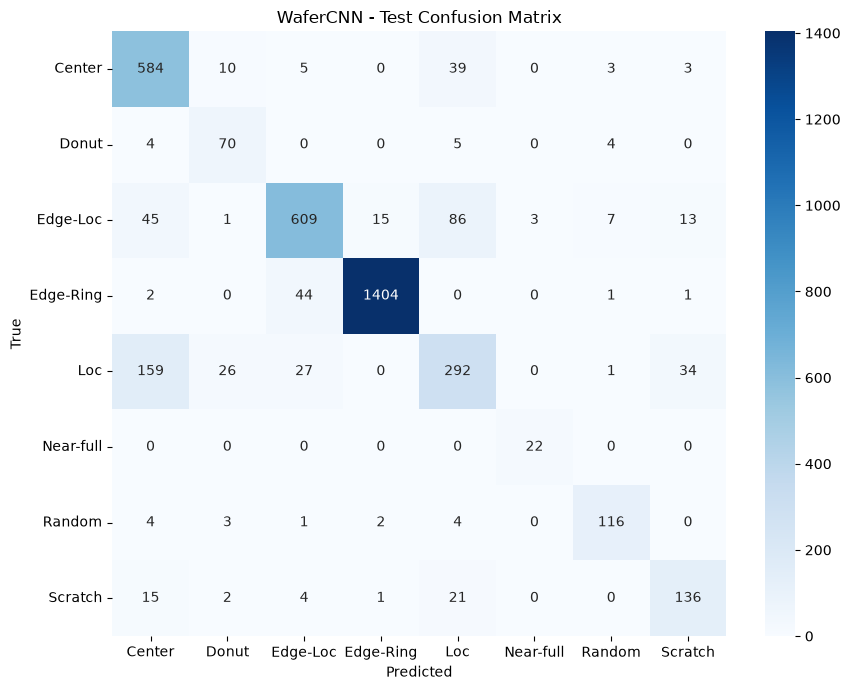

In [34]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the best checkpoint, not the last-epoch weights
model.load_state_dict(torch.load(best_path, map_location=DEVICE))

# Evaluate once on the held-out test set
test_loss, test_preds, test_labels = evaluate(model=model, loader=test_loader, criterion=criterion, device=DEVICE)
print(f"Test loss: {test_loss:.4f}")

# Per class precision, recall, and F1 - the real evaluation
print(classification_report(y_true=test_labels, y_pred=test_preds, target_names=LABELS, digits=3))

# Confusion matrix
cm = confusion_matrix(y_true=test_labels, y_pred=test_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("WaferCNN - Test Confusion Matrix")
plt.tight_layout()

cm_path = MODEL_DIR / "confusion_matrix.png"
plt.savefig(cm_path, dpi=120, bbox_inches="tight")
plt.show()
# print(f"Saved confusion matrix to {cm_path}")cm_path



# Baseline model Diagnosis & Next steps
The baseline CNN reaches ** macro-F1 0.785 / accuracy 0.833 ** on the held-out test set - a healthy starting point for a ~94k-param model trained from scratch. The confusion matrix reveals where it actually strugglesm which overturns out initial assumption.

### What the confusion matrix shows

**1. Rare classes are not the problem.**

Near-full (the rarest class, 22 test samples) has the recall of 1.000 - the model misses none of them. This confirms `WeightRandomSampler` is working as expected: oversampling gave the rare classes enough signal to be learned. Near-full precision is lower at 0.564, i.e. the model occasionally over-predicts it - an acceptable trade-off and a known side effect of oversampling.

**2. The real weakness is the Center <-> Loc confusion.**

186 treu-Center wafers are misclassified as Loc, dragging Center recall down to 0.668. Loc itself is the weaknest class (F1 0.647): its column absorbs the errors from Center, Edge-Loc, and Scratch, with precision 0.576. Loc is acting as a "catch-all" - when the model is unsure, it predicts Loc.

**3. Edge-Loc <-> Edge-Ring confusion (105 wafers).**

Geometrically, reasonable - both are edge-region defects with similar shapes. Less concerning than the Loc catch-all behavior.

### Diagnosing the val_loss instability

During training, `val_loss` oscillated sharply. The confusion matrix rules out the rare-class hypothesis: the small classes are well-classified, so the instability is **global oscillation**, not noise from tiny class supports. The root cause is a **fixed learning rate (1e-3) that stays too high late in training** - large update steps make the model bounce around the optimum instead of settling.

### Three possible directions

| Option                            | What it does                                                                    | Cost    | When                                          |
|-----------------------------------|---------------------------------------------------------------------------------|---------|-----------------------------------------------|
| **A. LR scheduler**               | Reduce LR when val_loss stalls → smoother convergence, possibly higher macro-F1 | ~10 min | **Now** — diagnosis confirmed LR is the cause |
| **B. ResNet-18 from scratch**     | Higher capacity may resolve Center/Loc confusion on its own                     | longer  | After baseline is finalized                   |
| **C. Inspect Center→Loc samples** | Visualize misclassified wafers to understand the confusion                      | short   | Better handled later via Grad-CAM             |

We proceed with **Option A first** (cheap, diagnosis-confirmed), keeping the original run for a
clean before/after comparison in MLflow, then move to Option B (ResNet-18) with a solid,
finalized baseline as the comparison anchor.

### Why ReduceLROnPlateau (not a fixed schedule)

`ReduceLROnPlateau` watches val_loss and only lowers the LR when improvement stalls — it reacts
to the actual training signal rather than following a predetermined curve. This directly targets
the observed symptom (val_loss plateauing then bouncing), which is the principled choice given
what the diagnosis showed.

In [35]:
# Fresh model + optimizer so this run trains from scratch. Class is still defined once in the above cell.
model = WaferCNN().to(device=DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode="min", factor=0.5,
                                                       patience=3)  # LR scheduler: halve learning rate after val_loss stalls for 3 epochs

run_params = {
    "model": "WaferCNN",
    "epochs": EPOCHS,
    "batch_size": BATCH,
    "lr": LR,
    "optimizer": "Adam",
    "loss": "CrossEntropyLoss",
    "sampler": "WeightedRandomSampler",
    "scheduler": "ReduceLROnPlateau(factor=0.5, patience=3)",
    "seed": SEED,
    "img_size": 64,
    "num_classes": NUM_CLASSES,
}

with mlflow.start_run(run_name="baseline-cnn-scheduler"):
    mlflow.log_params(run_params)
    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model=model, loader=train_loader, criterion=criterion, optimizer=optimizer,
                                     device=DEVICE)
        val_loss, val_preds, val_labels = evaluate(model=model, loader=val_loader, criterion=criterion, device=DEVICE)
        scheduler.step(val_loss)
        val_macro_f1 = f1_score(y_true=val_labels, y_pred=val_preds, average="macro")
        scheduler.step(val_loss)  # feed val_loss to scheduler
        current_lr = optimizer.param_groups[0]["lr"]

        mlflow.log_metrics(
            metrics={
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_macro_f1": val_macro_f1,
                "lr": current_lr,
            }, step=epoch
        )
        print(
            f"epoch {epoch:2d} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | val macro-F1: {val_macro_f1:.4f} | lr: {current_lr:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_path)
            mlflow.log_artifact(str(best_path))
            print(f"\t-> saved best (val_loss {val_loss:.4f})")

print(f"\nDone! Best val_loss: {best_val_loss:.4f}")

epoch  1 | train loss: 1.1229 | val loss: 1.0256 | val macro-F1: 0.4785 | lr: 0.0010
epoch  2 | train loss: 0.8140 | val loss: 1.0695 | val macro-F1: 0.5646 | lr: 0.0010
epoch  3 | train loss: 0.7177 | val loss: 1.2417 | val macro-F1: 0.5386 | lr: 0.0005
epoch  4 | train loss: 0.6526 | val loss: 0.7783 | val macro-F1: 0.5946 | lr: 0.0005
epoch  5 | train loss: 0.6032 | val loss: 0.7971 | val macro-F1: 0.6126 | lr: 0.0005
epoch  6 | train loss: 0.5894 | val loss: 0.9224 | val macro-F1: 0.5615 | lr: 0.0003
epoch  7 | train loss: 0.5455 | val loss: 0.6019 | val macro-F1: 0.6972 | lr: 0.0003
epoch  8 | train loss: 0.5359 | val loss: 0.5529 | val macro-F1: 0.7006 | lr: 0.0003
epoch  9 | train loss: 0.5120 | val loss: 0.5828 | val macro-F1: 0.7110 | lr: 0.0003
epoch 10 | train loss: 0.5135 | val loss: 0.6330 | val macro-F1: 0.7023 | lr: 0.0001
epoch 11 | train loss: 0.4942 | val loss: 0.5302 | val macro-F1: 0.7368 | lr: 0.0001
epoch 12 | train loss: 0.4864 | val loss: 0.5719 | val macro-F1: 

Test loss: 0.3912
              precision    recall  f1-score   support

      Center      0.718     0.907     0.802       644
       Donut      0.625     0.843     0.718        83
    Edge-Loc      0.883     0.782     0.829       779
   Edge-Ring      0.987     0.967     0.977      1452
         Loc      0.653     0.542     0.592       539
   Near-full      0.880     1.000     0.936        22
      Random      0.879     0.892     0.885       130
     Scratch      0.727     0.760     0.743       179

    accuracy                          0.845      3828
   macro avg      0.794     0.837     0.810      3828
weighted avg      0.849     0.845     0.843      3828



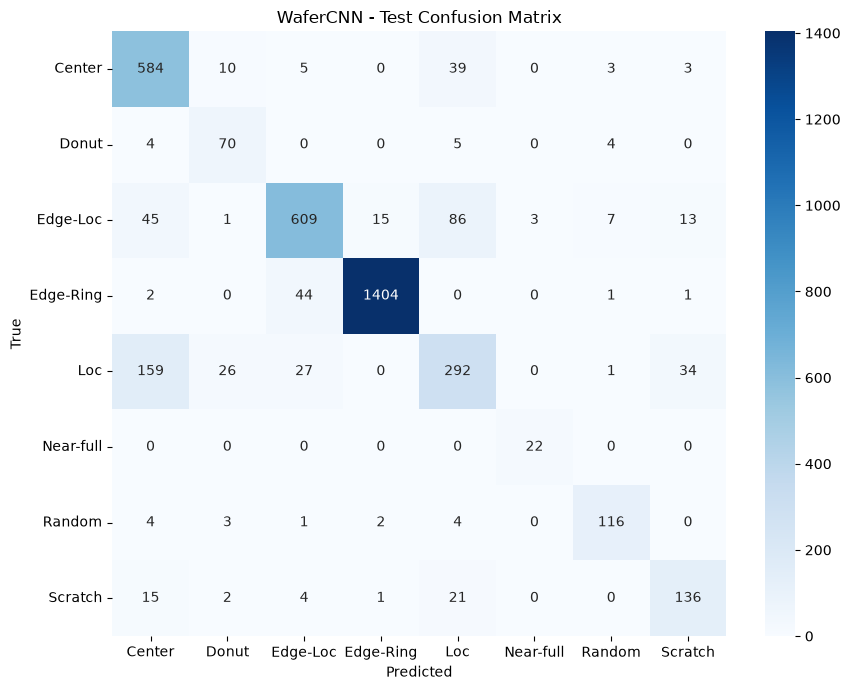

In [36]:
# Load the best checkpoint, not the last-epoch weights
model.load_state_dict(torch.load(best_path, map_location=DEVICE))

# Evaluate once on the held-out test set
test_loss, test_preds, test_labels = evaluate(model=model, loader=test_loader, criterion=criterion, device=DEVICE)
print(f"Test loss: {test_loss:.4f}")

# Per class precision, recall, and F1 - the real evaluation
print(classification_report(y_true=test_labels, y_pred=test_preds, target_names=LABELS, digits=3))

# Confusion matrix
cm = confusion_matrix(y_true=test_labels, y_pred=test_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("WaferCNN - Test Confusion Matrix")
plt.tight_layout()

cm_path = MODEL_DIR / "confusion_matrix_scheduler.png"
plt.savefig(cm_path, dpi=120, bbox_inches="tight")
plt.show()
# print(f"Saved confusion matrix to {cm_path}")

In [37]:
def run_experiment(model, run_name, train_loader, val_loader, epochs=EPOCHS, lr=LR, es_patience=7):
    """Train a model with Mlflow logging, LR scheduling, and early stopping. Returns the path to the best checkpoint by val_loss"""
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode="min", factor=0.5, patience=3)
    best_val_loss = float("inf")
    epochs_no_improve = 0
    MODEL_DIR.mkdir(exist_ok=True)
    best_path = MODEL_DIR / f"{run_name}_best.pt"
    run_params = {
        "model": run_name,
        "epochs": epochs,
        "batch_size": BATCH,
        "lr": lr,
        "optimizer": "Adam",
        "loss": "CrossEntropyLoss",
        "sampler": "WeightedRandomSampler",
        "scheduler": "ReduceLROnPlateau(factor=0.5, patience=3)",
        "early_stopping_patience": es_patience,
        "seed": SEED,
        "img_size": 64,
        "num_classes": NUM_CLASSES,
    }

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(run_params)
        for epoch in range(1, epochs + 1):
            train_loss = train_one_epoch(model=model, loader=train_loader, criterion=criterion, optimizer=optimizer,
                                         device=DEVICE)
            val_loss, val_preds, val_labels = evaluate(model=model, loader=val_loader, criterion=criterion,
                                                       device=DEVICE)
            val_macro_f1 = f1_score(y_true=val_labels, y_pred=val_preds, average="macro")

            scheduler.step(metrics=val_loss)
            current_lr = optimizer.param_groups[0]["lr"]

            mlflow.log_metrics(
                {"train_loss": train_loss, "val_loss": val_loss, "val_macro_f1": val_macro_f1, "lr": current_lr},
                step=epoch)

            print(
                f"epoch {epoch:2d} | train {train_loss:.4f} | val_loss {val_loss:.4f} | val_macro-F1: {val_macro_f1:.4f} | lr: {current_lr:.2e}")

            # track the best + early stopping counter
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_no_improve = 0
                torch.save(model.state_dict(), best_path)
                mlflow.log_artifact(str(best_path))
                print(f"\t-> saved best (val_loss {val_loss:.4f})")
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= es_patience:
                    print(f"\t-> early stopping at epoch {epoch} (no improvement for {epochs_no_improve} epochs)")
                    break
    print(f"Done! Best val_loss: {best_val_loss:.4f}")
    return best_path

In [38]:
def evaluate_and_report(best_path, model, loader, title, device=DEVICE):
    """Load best checkpoint, run per-class report + confusion matrix on loader"""
    model = model.to(device=device)
    model.load_state_dict(torch.load(best_path, map_location=device))
    test_loss, test_preds, test_labels = evaluate(model=model, loader=loader, criterion=criterion, device=device)
    print(f"Test loss for {title}: {test_loss:.4f}")
    print(classification_report(y_true=test_labels, y_pred=test_preds, target_names=LABELS, digits=3))

    cm = confusion_matrix(y_true=test_labels, y_pred=test_preds)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{title} - Test Confusion Matrix")
    plt.tight_layout()

    cm_path = MODEL_DIR / f"{title}_confusion_matrix.png"
    plt.savefig(cm_path, dpi=120, bbox_inches="tight")
    plt.show()
    # print(f"Saved confusion matrix to {cm_path}")
    return cm_path

epoch  1 | train 1.1245 | val_loss 0.9388 | val_macro-F1: 0.5081 | lr: 1.00e-03
	-> saved best (val_loss 0.9388)
epoch  2 | train 0.8072 | val_loss 1.0059 | val_macro-F1: 0.5515 | lr: 1.00e-03
epoch  3 | train 0.7080 | val_loss 0.7029 | val_macro-F1: 0.6030 | lr: 1.00e-03
	-> saved best (val_loss 0.7029)
epoch  4 | train 0.6521 | val_loss 0.6036 | val_macro-F1: 0.6925 | lr: 1.00e-03
	-> saved best (val_loss 0.6036)
epoch  5 | train 0.5997 | val_loss 1.3809 | val_macro-F1: 0.4883 | lr: 1.00e-03
epoch  6 | train 0.5651 | val_loss 0.6146 | val_macro-F1: 0.6881 | lr: 1.00e-03
epoch  7 | train 0.5528 | val_loss 0.7810 | val_macro-F1: 0.6263 | lr: 1.00e-03
epoch  8 | train 0.5157 | val_loss 0.5659 | val_macro-F1: 0.7250 | lr: 1.00e-03
	-> saved best (val_loss 0.5659)
epoch  9 | train 0.5115 | val_loss 0.5572 | val_macro-F1: 0.6740 | lr: 1.00e-03
	-> saved best (val_loss 0.5572)
epoch 10 | train 0.4811 | val_loss 0.4828 | val_macro-F1: 0.7704 | lr: 1.00e-03
	-> saved best (val_loss 0.4828)
ep

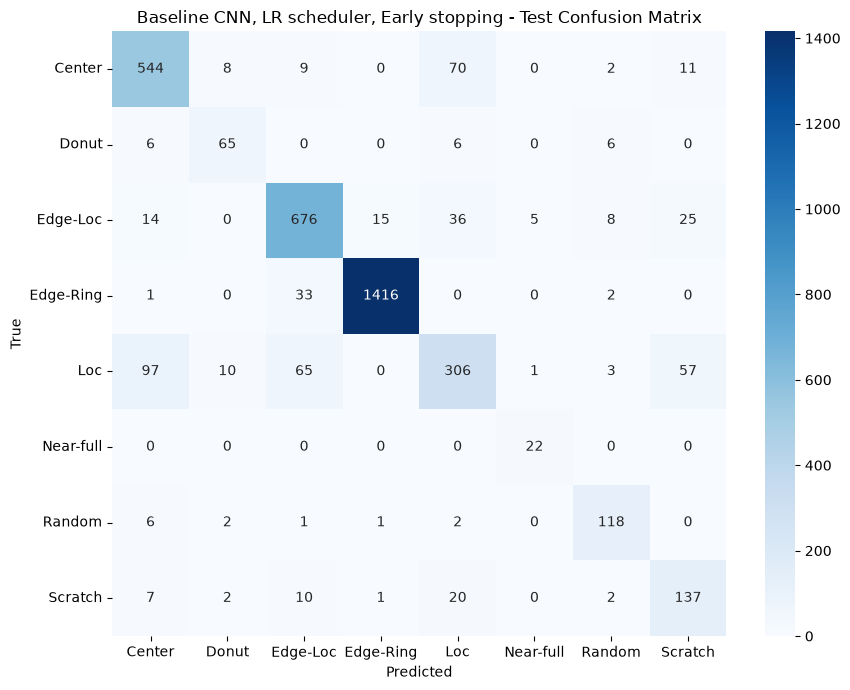

In [39]:
cnn = WaferCNN()
cnn_best_path = run_experiment(model=cnn, run_name="baseline-cnn-scheduler-earlystop", train_loader=train_loader,
                               val_loader=val_loader)
_ = evaluate_and_report(best_path=cnn_best_path, model=cnn, loader=test_loader,
                        title="Baseline CNN, LR scheduler, Early stopping")

In [40]:
def run_experiment_f1(model, run_name, train_loader, val_loader, epochs=EPOCHS, lr=LR, es_patience=7):
    """Train a model with Mlflow logging, LR scheduling, and early stopping. Returns the path to the best checkpoint by val macro-F1"""
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode="min", factor=0.5, patience=3)
    best_val_f1 = -float("inf")
    epochs_no_improve = 0
    MODEL_DIR.mkdir(exist_ok=True)
    best_path = MODEL_DIR / f"{run_name}_best.pt"
    run_params = {
        "model": run_name,
        "epochs": epochs,
        "batch_size": BATCH,
        "lr": lr,
        "optimizer": "Adam",
        "loss": "CrossEntropyLoss",
        "sampler": "WeightedRandomSampler",
        "scheduler": "ReduceLROnPlateau(factor=0.5, patience=3)",
        "early_stopping_patience": es_patience,
        "seed": SEED,
        "img_size": 64,
        "num_classes": NUM_CLASSES,
    }

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(run_params)
        for epoch in range(1, epochs + 1):
            train_loss = train_one_epoch(model=model, loader=train_loader, criterion=criterion, optimizer=optimizer, device=DEVICE)
            val_loss, val_preds, val_labels = evaluate(model=model, loader=val_loader, criterion=criterion, device=DEVICE)
            val_macro_f1 = f1_score(y_true=val_labels, y_pred=val_preds, average="macro")

            scheduler.step(metrics=val_loss) # scheduler react to loss not F1
            current_lr = optimizer.param_groups[0]["lr"]

            mlflow.log_metrics(
                {"train_loss": train_loss, "val_loss": val_loss, "val_macro_f1": val_macro_f1, "lr": current_lr},
                step=epoch
            )

            print(  
                f"epoch {epoch:2d} | train {train_loss:.4f} | val_loss {val_loss:.4f} | val_macro-F1: {val_macro_f1:.4f} | lr: {current_lr:.2e}"
            )

            # track the best + early stopping counter
            if val_macro_f1 > best_val_f1:
                best_val_f1 = val_macro_f1
                epochs_no_improve = 0
                torch.save(model.state_dict(), best_path)
                mlflow.log_artifact(str(best_path))
                print(f"\t-> saved best (val_macro-F1 {val_macro_f1:.4f})")
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= es_patience:
                    print(f"\t-> early stopping at epoch {epoch} (no improvement for {epochs_no_improve} epochs)")
                    break
                
    print(f"Done! Best val_macro-F1: {best_val_f1:.4f}")
    return best_path

epoch  1 | train 1.1104 | val_loss 1.1476 | val_macro-F1: 0.4931 | lr: 1.00e-03
	-> saved best (val_loss 1.1476)
epoch  2 | train 0.8060 | val_loss 1.5546 | val_macro-F1: 0.4601 | lr: 1.00e-03
epoch  3 | train 0.7080 | val_loss 0.9071 | val_macro-F1: 0.6636 | lr: 1.00e-03
	-> saved best (val_loss 0.9071)
epoch  4 | train 0.6442 | val_loss 0.6031 | val_macro-F1: 0.6998 | lr: 1.00e-03
	-> saved best (val_loss 0.6031)
epoch  5 | train 0.5905 | val_loss 1.8210 | val_macro-F1: 0.4696 | lr: 1.00e-03
epoch  6 | train 0.5649 | val_loss 0.7247 | val_macro-F1: 0.6429 | lr: 1.00e-03
epoch  7 | train 0.5357 | val_loss 1.4355 | val_macro-F1: 0.5214 | lr: 1.00e-03
epoch  8 | train 0.5088 | val_loss 0.8089 | val_macro-F1: 0.6297 | lr: 5.00e-04
epoch  9 | train 0.4763 | val_loss 0.6579 | val_macro-F1: 0.6829 | lr: 5.00e-04
epoch 10 | train 0.4525 | val_loss 0.4499 | val_macro-F1: 0.7627 | lr: 5.00e-04
	-> saved best (val_loss 0.4499)
epoch 11 | train 0.4407 | val_loss 0.6950 | val_macro-F1: 0.6425 | l

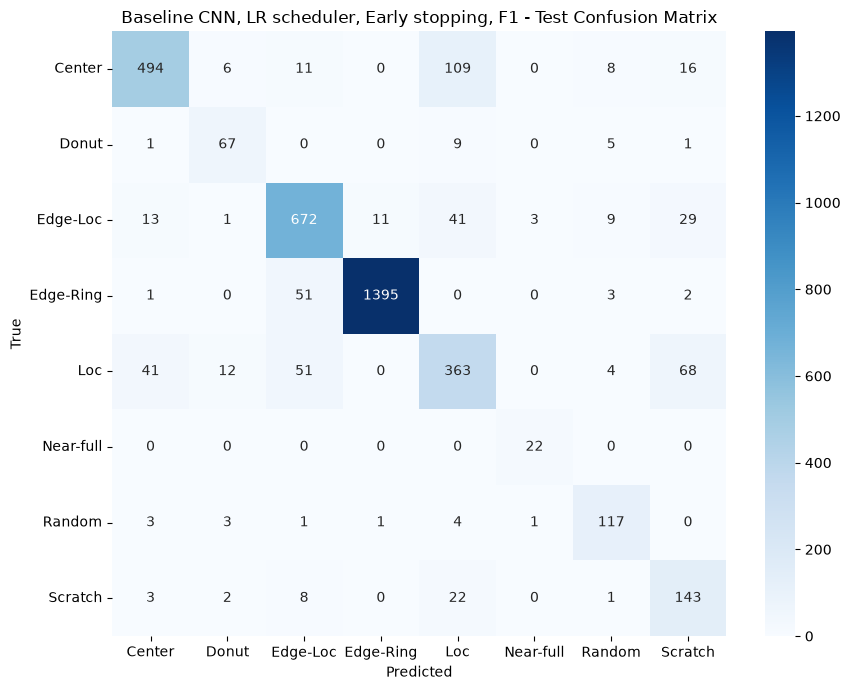

In [41]:
cnn = WaferCNN()
cnn_best_path = run_experiment(
    model=cnn,
    run_name="baseline-cnn-scheduler-earlystop-f1",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50,
    es_patience=15,
)
_ = evaluate_and_report(
    best_path=cnn_best_path,
    model=cnn,
    loader=test_loader,
    title="Baseline CNN, LR scheduler, Early stopping, F1",
)

In [42]:
def run_experiment_f1_checkpoint_only(
    model, run_name, train_loader, val_loader, epochs=EPOCHS, lr=LR, es_patience=7
):
    """Train a model with Mlflow logging, LR scheduling, and early stopping. Returns the path to the best checkpoint by val macro-F1"""
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer=optimizer, mode="min", factor=0.5, patience=3
    )
    best_val_f1 = -float("inf")
    best_val_loss = float("inf")
    epochs_no_improve = 0
    MODEL_DIR.mkdir(exist_ok=True)
    best_path = MODEL_DIR / f"{run_name}_best.pt"
    run_params = {
        "model": run_name,
        "epochs": epochs,
        "batch_size": BATCH,
        "lr": lr,
        "optimizer": "Adam",
        "loss": "CrossEntropyLoss",
        "sampler": "WeightedRandomSampler",
        "scheduler": "ReduceLROnPlateau(factor=0.5, patience=3)",
        "early_stopping_patience": es_patience,
        "seed": SEED,
        "img_size": 64,
        "num_classes": NUM_CLASSES,
    }

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(run_params)
        for epoch in range(1, epochs + 1):
            train_loss = train_one_epoch(
                model=model,
                loader=train_loader,
                criterion=criterion,
                optimizer=optimizer,
                device=DEVICE,
            )
            val_loss, val_preds, val_labels = evaluate(
                model=model, loader=val_loader, criterion=criterion, device=DEVICE
            )
            val_macro_f1 = f1_score(
                y_true=val_labels, y_pred=val_preds, average="macro"
            )

            scheduler.step(metrics=val_loss)  # scheduler react to loss not F1
            current_lr = optimizer.param_groups[0]["lr"]

            mlflow.log_metrics(
                {
                    "train_loss": train_loss,
                    "val_loss": val_loss,
                    "val_macro_f1": val_macro_f1,
                    "lr": current_lr,
                },
                step=epoch,
            )

            print(
                f"epoch {epoch:2d} | train {train_loss:.4f} | val_loss {val_loss:.4f} | val_macro-F1: {val_macro_f1:.4f} | lr: {current_lr:.2e}"
            )

            # track the best macro-F1 to save the best model
            if val_macro_f1 > best_val_f1:
                best_val_f1 = val_macro_f1
                torch.save(model.state_dict(), best_path)
                mlflow.log_artifact(str(best_path))
                print(f"\t-> saved best (val_macro-F1 {val_macro_f1:.4f})")
                
            # track the best val_loss to update the early stopping counter
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_no_improve = 0
                print(f"\t-> saved best (val_loss {val_loss:.4f})")
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= es_patience:
                    print(
                        f"\t-> early stopping at epoch {epoch} (no improvement for {epochs_no_improve} epochs)"
                    )
                    break

    print(f"Done! Best val_macro-F1: {best_val_f1:.4f}")
    return best_path

epoch  1 | train 1.1028 | val_loss 0.9360 | val_macro-F1: 0.5605 | lr: 1.00e-03
	-> saved best (val_macro-F1 0.5605)
	-> saved best (val_loss 0.9360)
epoch  2 | train 0.8147 | val_loss 0.9110 | val_macro-F1: 0.5809 | lr: 1.00e-03
	-> saved best (val_macro-F1 0.5809)
	-> saved best (val_loss 0.9110)
epoch  3 | train 0.7064 | val_loss 3.6657 | val_macro-F1: 0.3176 | lr: 1.00e-03
epoch  4 | train 0.6544 | val_loss 1.7372 | val_macro-F1: 0.4812 | lr: 1.00e-03
epoch  5 | train 0.6209 | val_loss 0.6863 | val_macro-F1: 0.6167 | lr: 1.00e-03
	-> saved best (val_macro-F1 0.6167)
	-> saved best (val_loss 0.6863)
epoch  6 | train 0.5803 | val_loss 1.1331 | val_macro-F1: 0.5790 | lr: 1.00e-03
epoch  7 | train 0.5674 | val_loss 0.5744 | val_macro-F1: 0.7075 | lr: 1.00e-03
	-> saved best (val_macro-F1 0.7075)
	-> saved best (val_loss 0.5744)
epoch  8 | train 0.5247 | val_loss 0.5958 | val_macro-F1: 0.6699 | lr: 1.00e-03
epoch  9 | train 0.4964 | val_loss 1.3623 | val_macro-F1: 0.5196 | lr: 1.00e-03


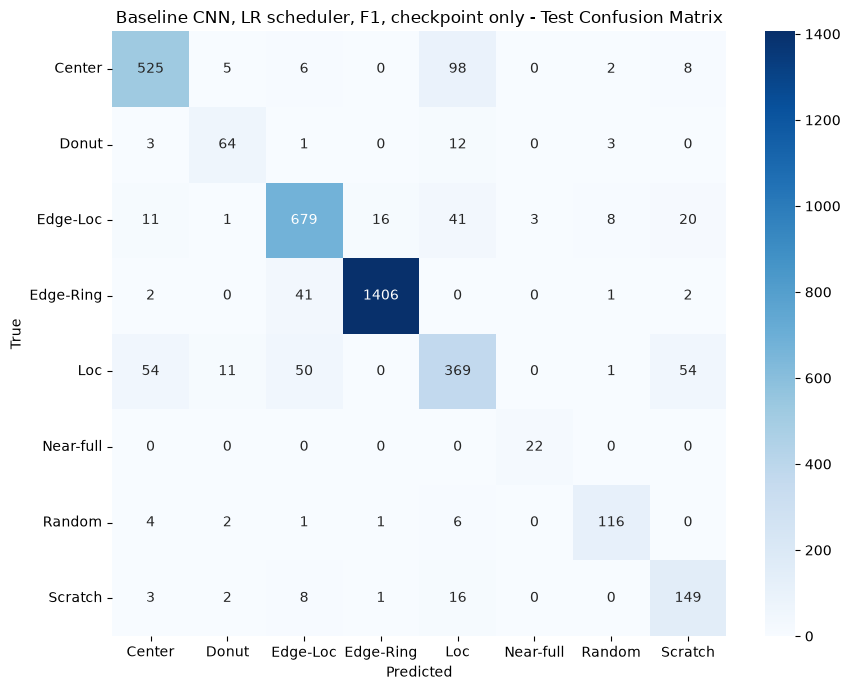

In [43]:
cnn = WaferCNN()
cnn_best_path = run_experiment_f1_checkpoint_only(
    model=cnn,
    run_name="baseline-cnn-scheduler-f1-checkpoint-only",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50,
    es_patience=15,
)
_ = evaluate_and_report(
    best_path=cnn_best_path,
    model=cnn,
    loader=test_loader,
    title="Baseline CNN, LR scheduler, F1, checkpoint only",
)

In [44]:
import torch.nn as nn
import torch.nn.functional as F

class BasicBlock(nn.Module):
    """Standard ResNet BasicBlock: two 3x3 conv with a residual connection
    The skip connection is the whole point of ResNet: it lets the gradient flow directly past the conv layers (identity path), so deep networks stay trainable instead of degrading. expansion=1 means output channels == `out_channels`
    """
    expansion = 1
    
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        # First conv carries the stride: this is where spatial downsampling happens
        # at the start of stages 2/3/4 (stride=2). padding=1 keep 3x3 size-preserving
        # when stride=1. bias=False because BN right after has it own shift term.
    